# Land Cover and Land Use Classification of Kabul City Using Sentinel-2 and Machine Learning in Python

The primary goal of this project is to analyze and classify land cover and land use (LCLU) in Kabul City using Sentinel-2 imagery and machine learning techniques in Python. Specifically, the project will aim to:

- Automate the classification of key LCLU types, including built-up areas, water bodies, vegetation, and bare land.
- Develop a robust Random Forest classification model using training samples prepared in ArcGIS Pro.
- Integrate spectral indices such as NDVI, NDWI, and NDBI to enhance classification accuracy.
- Produce high-resolution, accurate LCLU maps of Kabul City to support urban planning, environmental monitoring, and decision-making.

By the end of this project, a fully documented workflow will be produced, covering imagery acquisition in Google Earth Engine, data preprocessing, land cover classification, model evaluation, and result visualization in Python. Final maps will be created in ArcGIS Pro, and a story map will be developed to effectively communicate the methods and outcomes.

## Kabul City Image Preparation
I downloaded Sentinel-2 imagery for Kabul City from Google Earth Engine, using six key spectral bands: B2, B3, B4, B8, B11, and B12. These bands were selected to minimize storage requirements and reduce processing time while still capturing essential spectral information needed for LCLU classification.

To enhance the classification accuracy, I also generated three spectral indices (NDVI, NDWI, and NDBI) and added them as additional bands to the image.

### Loading Kabul sentinel imagery

In [1]:
#Import packages
import arcpy
from arcpy.sa import *

# Set overwriteOutput to True to allow overwriting existing files
arcpy.env.overwriteOutput = True

# Specify the path to the Kabul image file
file = r"N:\Third_Semester\Python\Project\Kabul_S2_UTM.tif"

# Create a raster object from the Kabul image file
kabul_imagery = Raster(file)

### Getting Kabul Imagery's necesary information

In [2]:
# Get the pixel size in the x-direction (width) of the Kabul image raster
pixel_size_x = kabul_imagery.meanCellWidth

# Get the pixel size in the y-direction (height) of the Kabul image raster
pixel_size_y = kabul_imagery.meanCellHeight

# Print the pixel size in the x-direction (width) of the Kabul image raster
print(pixel_size_x)

# Print the pixel size in the y-direction (height) of the Kabul image raster
print(pixel_size_y)

10.0
10.0


In [3]:
# Get the extent (bounding box) of the Kabul image raster
extent = kabul_imagery.extent

# Display the extent frame
extent

XMin (Left),497980.000000
XMax (Right),533130.000000
YMin (Bottom),3809250.000000
YMax (Top),3829860.000000
name (Projected Coordinate System),WGS_1984_UTM_Zone_42N
factoryCode (WKID),32642
linearUnitName (Linear Unit),Meter
name (Geographic Coordinate System),GCS_WGS_1984
factoryCode (WKID),4326
angularUnitName (Angular Unit),Degree
datumName (Datum),D_WGS_1984


In [4]:
# Create a Point object representing the lower-left corner of Kabul imagery extent
lower_left_corner = arcpy.Point(extent.XMin, extent.YMin)

# get spatial reference
spatialReference = kabul_imagery.spatialReference

# Print the band names of the Kabul image file raster
print(kabul_imagery.bandNames)

['B2', 'B3', 'B4', 'B8', 'B11', 'B12']


### Indices
To improve my classification results, I added three below spectral indices as additional bands to the Kabul City Sentinel-2 imagery:

- NDVI (Normalized Difference Vegetation Index): Enhances the separation of vegetated and non-vegetated areas, making it easier for the classifier to identify vegetation accurately.

- NDWI (Normalized Difference Water Index): Improves the detection of water bodies by highlighting moisture content, reducing confusion with shadows or dark surfaces.

- NDBI (Normalized Difference Built-up Index): Strengthens the identification of built-up and urban areas by emphasizing surfaces with high reflectance in the SWIR range.

#### NDVI
NDVI is an index which is used to enhance the separation of vegetated and non-vegetated areas, making it easier for the classifier to identify vegetation accurately. Its formula is: NDVI = ((NIR - R)/(NIR + R)).

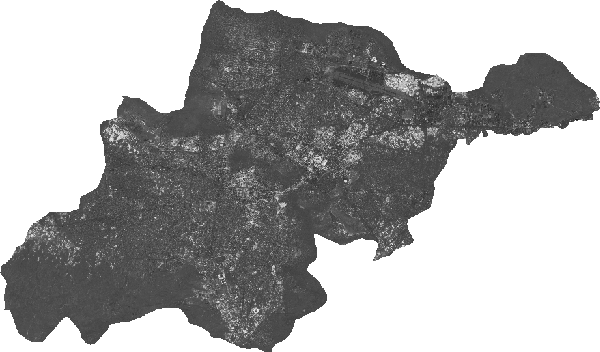

In [5]:
# Check out the Spatial Analyst extension for NDVI calculation
arcpy.CheckOutExtension("Spatial")

# Get the red (R) band (Band 4) from the Kabul image raster
red_band = kabul_imagery.getRasterBands('B4')

# Get the near-infrared (NIR) band (Band 8) from the Kabul image raster
nir_band = kabul_imagery.getRasterBands('B8')

# Introduce R and NIR band to their own responding bands
R = red_band
NIR = nir_band

# Using simple formula like algebra
NDVI = ((NIR - R)/(NIR + R))

# Display NDVI
NDVI

#### NDWI
NDWI is an index which is used to improve the detection of water bodies by highlighting moisture content, reducing confusion with shadows or dark surfaces. Its formula is: NDWI = ((G - NIR)/(G + NIR)).

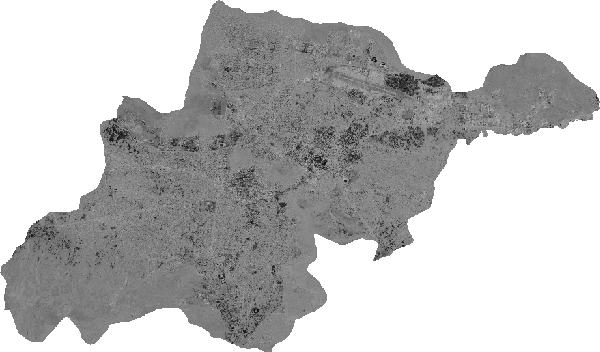

In [6]:
# Get the required bands
green_band = kabul_imagery.getRasterBands('B3')  # Green
swir_band = kabul_imagery.getRasterBands('B11')  # SWIR

# Assign to variables
G = green_band
SWIR = swir_band

# Calculate NDWI
NDWI = (G - NIR) / (G + NIR)

# Display NDWI
NDWI

#### NDBI
NDBI is an index which is used to Strengthen the identification of built-up and urban areas by emphasizing surfaces with high reflectance in the SWIR range.. Its formula is: NDBI = ((SWIR - NIR)/(SWIR + NIR)).

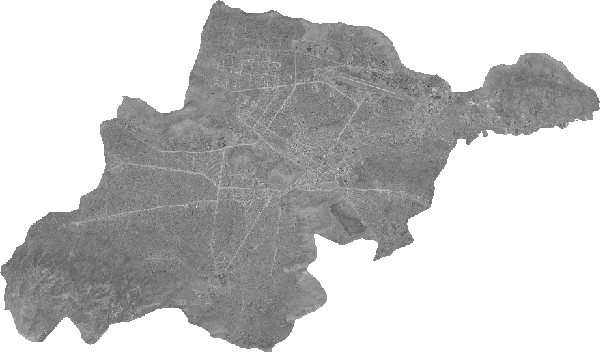

In [7]:
# Get the required bands
nir_band = kabul_imagery.getRasterBands('B8')  # NIR
swir_band = kabul_imagery.getRasterBands('B11')  # SWIR

# Assign to variables
NIR = nir_band
SWIR = swir_band

# Calculate NDBI
NDBI = (SWIR - NIR) / (SWIR + NIR)

# Display NDBI
NDBI

### Composite Bands
Adding NDVI, NDWI and NDBI as additional bands to the Kabul image

In [8]:
# Enable Spatial Analyst extension
arcpy.CheckOutExtension("Spatial")

# Output composite path
Kabul_Imagery_Indices = r"N:\Third_Semester\Python\Project\result\Kabul_Imagery_Indices.tif"

# Composite three indices into kabul sentinel imagery.
arcpy.management.CompositeBands(
    [kabul_imagery, NDVI, NDWI, NDBI],
    Kabul_Imagery_Indices
)

<Result 'N:\\Third_Semester\\Python\\Project\\result\\Kabul_Imagery_Indices.tif'>

#### Rename Bands
To ensure data quality, the composite image’s bands are renamed to their proper names.

In [9]:
# Import package
import rasterio

# Path for the new raster with renamed bands
output_file = r"N:\Third_Semester\Python\Project\result\Kabul_City_Imagery.tif"

# Desired new band names
new_band_names = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI", "NDBI"]

# Open the original raster
with rasterio.open(Kabul_Imagery_Indices) as src:
    # Copy metadata
    meta = src.meta.copy()
    
    # Read all bands into a list
    bands_data = [src.read(i + 1) for i in range(src.count)]
    
    # Update metadata if needed (optional)
    meta.update(count=len(bands_data))
    
    # Create a new file with the same data
    with rasterio.open(output_file, 'w', **meta) as dst:
        for i, band in enumerate(bands_data, start=1):
            dst.write(band, i)
            # Set band descriptions (names)
            dst.set_band_description(i, new_band_names[i-1])

print("Bands renamed successfully!")

Bands renamed successfully!


In [10]:
# verifying the band names of new file
Kabul_raster = r"N:\Third_Semester\Python\Project\result\Kabul_City_Imagery.tif"
kabul_Image = Raster(Kabul_raster)
print(kabul_Image.bandNames)

['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI']


### Display the Kabul City Image in Jupyter Notebook

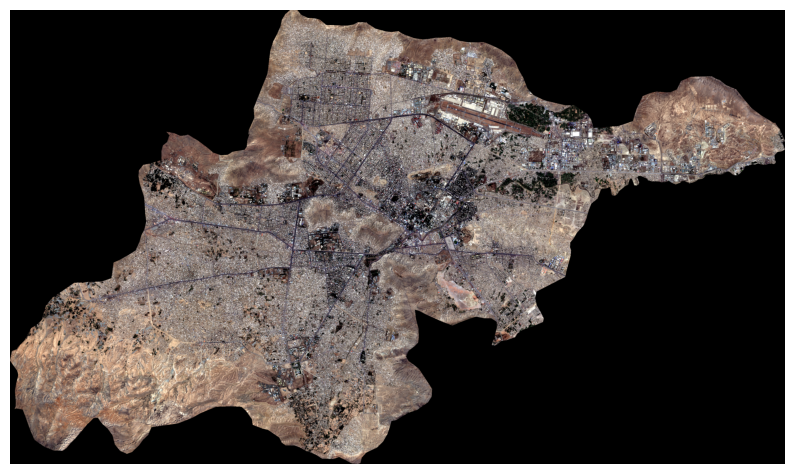

In [11]:
# Import packages
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Define the path file
raster_path = r"N:\Third_Semester\Python\Project\result\Kabul_City_Imagery.tif"

# Read and fix function to prepare bands for visualization
def read_and_fix(src, b):
    band = src.read(b).astype("float32")

    # Replace zeros and negatives 
    band[band <= 0] = np.nan

    # Clip extreme values
    vmin, vmax = np.nanpercentile(band, [1, 99])
    band = np.clip(band, vmin, vmax)

    # Normalize safely
    band = (band - vmin) / (vmax - vmin)
    band = np.nan_to_num(band)

    return band

# Read the file and prepare RGB visualization
with rasterio.open(raster_path) as src:
    # Choose RGB bands
    bands = [3, 2, 1]

    r = read_and_fix(src, bands[0])
    g = read_and_fix(src, bands[1])
    b = read_and_fix(src, bands[2])

# stack bands into an RGB image
rgb = np.dstack((r, g, b))

# Diplay the RGB image
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.axis("off")
plt.show()

## Supervised Classification Using Machine Learning
The training samples created in ArcGIS Pro were randomly split, with 80% used for training and 20% reserved for testing. The model was then evaluated, and the image was classified using a Random Forest classifier. Finally, the classification results were visualized.


In [12]:
# Import packages
import arcpy
import rasterio
import numpy as np
from rasterio.mask import mask
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Load training polygons using ArcPy
shp_path = r"N:\Third_Semester\Python\Project\Sample\Upadated_training_Samples.shp"

fields = ['SHAPE@', 'Classvalue']  # Geometry + numeric class
training_polygons = []

with arcpy.da.SearchCursor(shp_path, fields) as cursor:
    for row in cursor:
        training_polygons.append({'geometry': row[0], 'Classvalue': row[1]})


# Load Kabul City Image
raster = rasterio.open(r"N:\Third_Semester\Python\Project\result\\Kabul_City_Imagery.tif")

# Mapping numeric values to class names
class_mapping = {1: "Built-up", 2: "Bare_land", 3: "Vegetation", 4: "Road", 5: "Water"}


# Extract raster values under polygons
X = []  # features
y = []  # numeric labels

for row in training_polygons:
    geom = [row['geometry'].__geo_interface__]  # convert ArcPy geometry to geojson dict
    out_image, out_transform = mask(raster, geom, crop=True, nodata=raster.nodata)
    
    n_bands, h, w = out_image.shape
    pixels = out_image.reshape(n_bands, -1).T
    
    # Remove pixels with nodata
    if raster.nodata is not None:
        mask_valid = ~np.any(pixels == raster.nodata, axis=1)
        pixels = pixels[mask_valid]
    
    if pixels.size > 0:
        X.append(pixels)
        y.append(np.full(pixels.shape[0], row['Classvalue']))

# Combine all polygons
X = np.vstack(X)
y = np.concatenate(y)
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (41983, 9)
Labels shape: (41983,)


### Split Training samples
20% of the training samples are used for model evaluation, while 80% are used for training.

In [13]:
# Split into training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Source: https://www.datacamp.com/tutorial/random-forests-classifier-python

### Train the Model
The training samples are used to train the model

In [14]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Source: https://www.datacamp.com/tutorial/random-forests-classifier-python

RandomForestClassifier(random_state=42)

#### Model Evaluation
The model is evaluated using the testing samples and a confusion matrix, which summarizes the accuracy of its predictions.

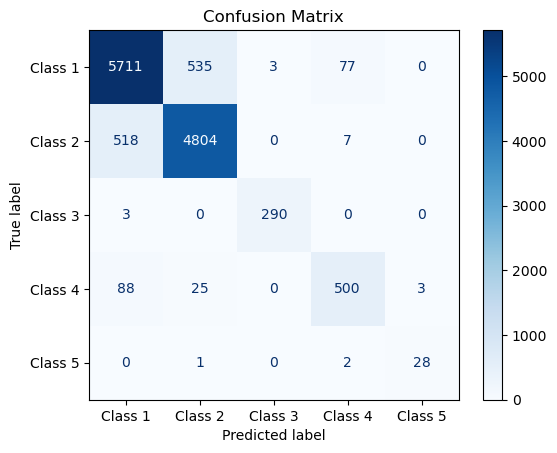

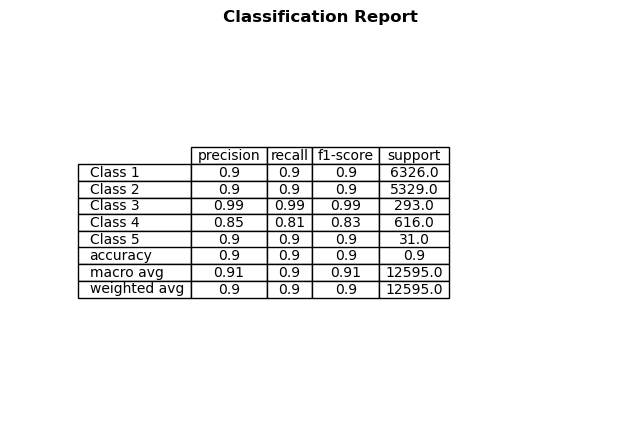

In [15]:
# Import packages
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Evaluate model
y_pred = rf.predict(X_test)

# Automatically get class names from y_test
unique_classes = np.unique(y_test)  # class labels in test set
class_names = [f'Class {i}' for i in unique_classes]  # or replace with actual names

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
cr = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
cr_df = pd.DataFrame(cr).transpose().round(2)

# Display as table using matplotlib
fig, ax = plt.subplots(figsize=(8, len(cr_df)*0.5 + 1))
ax.axis('off')  # hide axes

# Create table
table = ax.table(cellText=cr_df.values,
                 rowLabels=cr_df.index,
                 colLabels=cr_df.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(cr_df.columns))))

plt.title("Classification Report", fontweight='bold')
plt.show()

# Source: https://www.datacamp.com/tutorial/random-forests-classifier-python

In [16]:
# Import packages
from sklearn.metrics import cohen_kappa_score
import numpy as np

# Predict
y_pred = rf.predict(X_test)

# Kappa per class (one-vs-rest)
print("\nKappa per class:")
for cls in unique_classes:
    # Convert current class to binary (1 = current class, 0 = all others)
    y_test_binary = (y_test == cls).astype(int)
    y_pred_binary = (y_pred == cls).astype(int)
    
    kappa_cls = cohen_kappa_score(y_test_binary, y_pred_binary)
    print(f"{class_names[cls-1]}: {kappa_cls:.3f}")  # Adjust name if classes start at 1

# Calculate overall Kappa
overall_kappa = cohen_kappa_score(y_test, y_pred)
print(f"Overall Kappa: {overall_kappa:.3f}")



Kappa per class:
Class 1: 0.806
Class 2: 0.824
Class 3: 0.990
Class 4: 0.824
Class 5: 0.903
Overall Kappa: 0.823


### Classification
The trained model is used to classify the Kabul image.

In [17]:
# Classify full raster
img = raster.read()
n_bands, h, w = img.shape
X_raster = img.reshape(n_bands, -1).T

# Remove nodata pixels before prediction
if raster.nodata is not None:
    mask_valid = ~np.any(X_raster == raster.nodata, axis=1)
else:
    mask_valid = np.ones(X_raster.shape[0], dtype=bool)

y_raster_pred = np.zeros(X_raster.shape[0], dtype=np.uint8)
y_raster_pred[mask_valid] = rf.predict(X_raster[mask_valid])
y_raster_pred = y_raster_pred.reshape(h, w)

### Saving the Classification result in my directory

In [18]:
# Save Classified raster in my directory
output_path = r"N:\Third_Semester\Python\Project\result\Classification.tif"

with rasterio.open(
    output_path, "w",
    driver="GTiff",
    height=h,
    width=w,
    count=1,
    dtype=rasterio.uint8,
    crs=raster.crs,
    transform=raster.transform,
    nodata=0
) as dst:
    dst.write(y_raster_pred, 1)

### Display the classification result

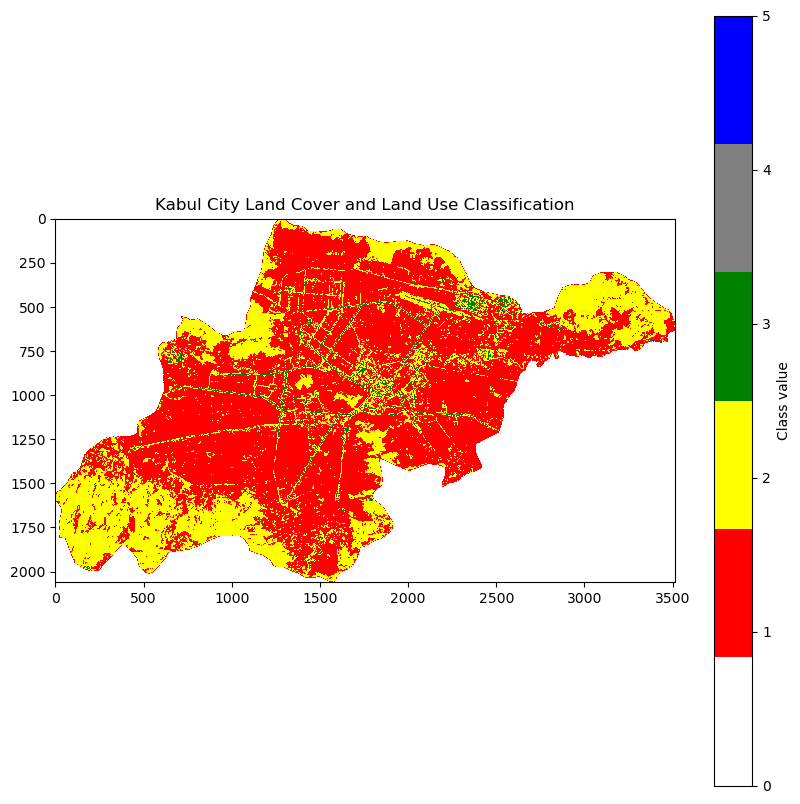

In [19]:
# Import packages for visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load the classified raster
raster_path = r"N:\Third_Semester\Python\Project\result\Classification.tif"

# Read classified raster
with rasterio.open(raster_path) as src:
    classified = src.read(1)  # read the first (and only) band

# Colors for each class
colors = ['white', 'red', 'yellow', 'green', 'gray', 'blue']

# list color map
cmap = ListedColormap(colors)

# Plot the classified raster
plt.figure(figsize=(10, 10))
plt.imshow(classified, cmap=cmap)
plt.title("Kabul City Land Cover and Land Use Classification")
plt.colorbar(ticks=[0,1,2,3,4,5], label='Class value')
plt.show()

# Acknowledgment
The majority of the code in this project was adapted from the Python Class (FW5553) at Michigan Technological University (instructor: Parth) and the tutorial available at https://www.datacamp.com/tutorial/random-forests-classifier-python. ChatGPT and Gemini were utilized to provide debugging assistance and support throughout the development of the project.